In [1]:
import numpy as np

In [22]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.9 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/8.9 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.9 MB 1.6 MB/s eta 0:00:05
   --------- ------------------------------ 2.1/8.9 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/8.9 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 1.9 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.9 MB 1.8 MB/s eta 0:00:04
   ----------------- ---------------------- 3.9/8.9 MB 1.9 MB/s eta 0:00:03
   --------------------- ------------------ 4.7/8.9 MB 2.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.5/8.9 MB 2.3 MB/s eta 0:00:02
   -----------------------

In [12]:
pip install pandas

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE", axis = 1)
y= df["PE"]

In [7]:
#Split out the data 

from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [10]:
import torch 
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor= torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [12]:
#Datasets and dataloader

from torch .utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep leanring part

In [14]:
#Build our ANN module 

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.model= nn.Sequential(
            #First hidden layer 
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            #second hoidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            #final layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [15]:
import torch.optim as optim

model = ANN()

#loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [19]:
 #Train the ANN
train_losses =[]
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #tot training loss for 1 epoch

    for xb, yb in train_loader:
        #xb = features of one batch
        #yb = labels of one batch
        optimizer.zero_grad() 

        outputs = model(xb) #foreard propagation.....predicted outputs for this batch
        loss = crietrion(outputs, yb) #compute loss
        loss.backward() #back prop... compute gradients
        optimizer.step() #params update

        running_loss += loss.item() #loss is tensor need to convert into py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss
    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val_loss = {epoch_val_loss}" )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 21.216599291563035 & val_loss = 19.456806182861328
epoch 2/100 ==> train loss = 21.223967953523 & val_loss = 21.204729080200195
epoch 3/100 ==> train loss = 21.316591425736746 & val_loss = 19.593463897705078
epoch 4/100 ==> train loss = 21.355697017908096 & val_loss = 19.711048126220703
epoch 5/100 ==> train loss = 21.22027802069982 & val_loss = 20.15399932861328
epoch 6/100 ==> train loss = 21.24146166642507 & val_loss = 19.702152252197266
epoch 7/100 ==> train loss = 21.249073155721028 & val_loss = 19.441621780395508
epoch 8/100 ==> train loss = 21.329540061950684 & val_loss = 19.50416374206543
epoch 9/100 ==> train loss = 21.324207452932992 & val_loss = 19.41852569580078
epoch 10/100 ==> train loss = 22.391167732079825 & val_loss = 19.97818374633789
epoch 11/100 ==> train loss = 21.369406370321908 & val_loss = 19.53251838684082
epoch 12/100 ==> train loss = 21.159292554855348 & val_loss = 19.761613845825195
epoch 13/100 ==> train loss = 21.39627705812454

In [28]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 3.8 MB/s  0:00:02
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------

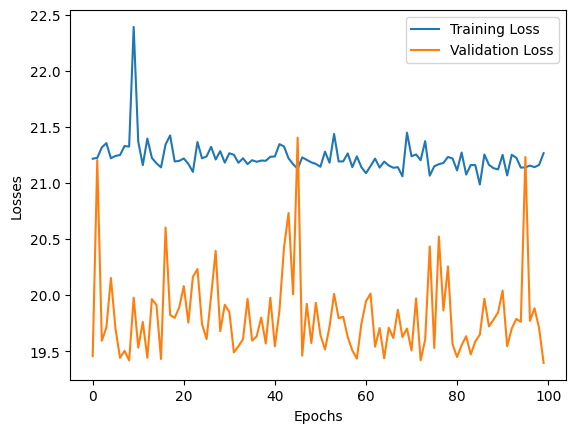

In [22]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

## Saving and Loading our best model

In [23]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

C:\Users\ARUN PUJARI\AppData\Local\Temp\ipykernel_19652\1155906715.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

## Evaluate the model

In [25]:
#Eval

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE", train_mse_loss.item())
print("Test MSE ", test_mse_loss.item())

Training MSE 20.847434997558594
Test MSE  19.401954650878906


In [26]:
from sklearn.metrics import r2_score

print("r2 score =", r2_score(y_test, test_preds))

r2 score = 0.9321951817089252
